# Loan Refinance Intelligence: End-to-End Technical Notebook

This notebook provides a complete technical walkthrough of the refinancing intelligence system.


## Problem Statement / Research Question

Can we build a data-driven refinancing intelligence pipeline that:
1. Identifies borrowers who are suitable candidates for refinancing,
2. Estimates achievable refinance rates and potential monthly savings,
3. Produces transparent recommendation outcomes for two pathways:
   - Credit Card to Personal Loan (`cc_to_pl`)
   - Personal Loan refinancing (`pl_refinance`)


## Data Sources and Structure

### Primary dataset
- LendingClub accepted loans (2007-2018): borrower profile, loan terms, pricing, and outcomes.

### Secondary dataset (optional in this notebook)
- Home Credit default dataset (`application_train.csv`) for future feature-transfer checks.

### Loading assumptions
1. We discover files from the current `data/raw` tree.
2. LendingClub primary file is selected by name/keyword match (largest match if duplicates).
3. Home Credit is optional and selected by exact file name `application_train.csv`.

### Core fields used
- Outcome and segmentation: `loan_status`, `purpose`
- Pricing and repayment: `int_rate`, `term`, `installment`
- Borrower profile: `annual_inc`, `dti`, `revol_util`, `revol_bal`, `grade`, `sub_grade`
- Credit signals: `fico_range_low`, `fico_range_high`, `delinq_2yrs`, `open_acc`
- Time axis: `issue_d`



## Techniques Used

1. **Data wrangling and governance**
   - Resolved/unresolved outcome labeling
   - Leakage exclusion policy
   - Data quality checks
2. **Feature engineering and selection**
   - Behavioral/ratio/log-transformed features
   - Correlation filtering
   - L1 Logistic + Lasso-based selection
3. **Model search and validation**
   - Temporal CV (`TimeSeriesSplit`)
   - Randomized search + grid refinement
   - Classification and regression model leaderboards
4. **Model families covered**
   - Logistic (L2/L1/ElasticNet), Random Forest, Linear SVM, RBF SVM
   - Ridge, Lasso, ElasticNet, Random Forest Regressor, Linear SVR, RBF SVR
5. **Probability quality and policy tuning**
   - Calibration (sigmoid)
   - Threshold sweep and policy optimization
6. **Recommendation layer**
   - Risk-adjusted savings and decision buckets
   - Policy simulation table for hold/savings thresholds
7. **Evaluation metrics**
   - Classification: PR-AUC, ROC-AUC, log loss, Brier, precision, recall, F1
   - Regression: RMSE, MAE, MAPE, R2


In [1]:
from pathlib import Path
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.exceptions import ConvergenceWarning, UndefinedMetricWarning

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module=r"sklearn\.linear_model\._logistic")
warnings.filterwarnings("ignore", message=".*Inconsistent values: penalty=l1.*")

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((p for p in ROOT_CANDIDATES if (p / "data").exists() and (p / "reports").exists()), Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.wrangling import apply_core_wrangling, resolved_modeling_frame, quality_checks, leakage_exclusions
from src.features.engineering import add_engineered_features, default_feature_columns
from src.features.selection import select_numeric_features_with_regularization
from src.models.search import classification_candidates, regression_candidates, run_search_suite
from src.evaluation.metrics import (
    classification_metrics_from_proba,
    regression_metrics,
    threshold_sweep,
    select_threshold,
)
from src.recommender.policy import apply_recommendation_policy, policy_simulation_table

DATA_RAW = PROJECT_ROOT / "data" / "raw"
REPORT_FIG = PROJECT_ROOT / "reports" / "figures"
REPORT_TAB = PROJECT_ROOT / "reports" / "tables"
REPORT_FIG.mkdir(parents=True, exist_ok=True)
REPORT_TAB.mkdir(parents=True, exist_ok=True)

# Runtime knobs to balance depth vs speed.
# Set FAST_MODE=1 for quick notebook iteration.
FAST_MODE = os.getenv("FAST_MODE", "0") == "1"

MODEL_MAX_ROWS = int(os.getenv("MODEL_MAX_ROWS", "180000"))
RANDOM_STATE = int(os.getenv("MODEL_RANDOM_STATE", "42"))
CV_SPLITS = int(os.getenv("MODEL_CV_SPLITS", "3"))
RANDOM_SEARCH_ITERS = int(os.getenv("MODEL_RANDOM_SEARCH_ITERS", "8"))
GRID_TOP_K = int(os.getenv("MODEL_GRID_TOP_K", "2"))
N_JOBS = int(os.getenv("MODEL_N_JOBS", "1"))
ENABLE_SVM = os.getenv("MODEL_ENABLE_SVM", "1") != "0"
MIN_PRECISION_FOR_THRESHOLD = float(os.getenv("MODEL_MIN_PRECISION", "0.25"))

if FAST_MODE:
    MODEL_MAX_ROWS = min(MODEL_MAX_ROWS, 5000)
    CV_SPLITS = min(CV_SPLITS, 2)
    RANDOM_SEARCH_ITERS = min(RANDOM_SEARCH_ITERS, 1)
    GRID_TOP_K = 0
    ENABLE_SVM = False
    N_JOBS = 1

print(f"Project root: {PROJECT_ROOT}")
print(
    f"FAST_MODE={FAST_MODE} | MODEL_MAX_ROWS={MODEL_MAX_ROWS} | CV_SPLITS={CV_SPLITS} | "
    f"RANDOM_SEARCH_ITERS={RANDOM_SEARCH_ITERS} | GRID_TOP_K={GRID_TOP_K} | "
    f"ENABLE_SVM={ENABLE_SVM} | MODEL_N_JOBS={N_JOBS}"
)







Project root: /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence
FAST_MODE=True | MODEL_MAX_ROWS=5000 | CV_SPLITS=2 | RANDOM_SEARCH_ITERS=1 | GRID_TOP_K=0 | ENABLE_SVM=False | MODEL_N_JOBS=1


In [2]:
def _read_csv_with_optional_usecols(path: Path, usecols=None, nrows=None):
    if usecols:
        header = pd.read_csv(path, nrows=0, low_memory=False)
        available = [c for c in usecols if c in header.columns]
        if available:
            return pd.read_csv(path, usecols=available, low_memory=False, nrows=nrows)
    return pd.read_csv(path, low_memory=False, nrows=nrows)


def discover_tabular_files(root: Path):
    return sorted(
        p for p in root.rglob("*")
        if p.is_file() and (p.suffix.lower() in {".csv", ".parquet"} or p.name.lower().endswith(".csv.gz"))
    )


def pick_lendingclub_file(files):
    preferred_names = {
        "accepted_2007_to_2018q4.csv.gz",
        "accepted_2007_to_2018q4.csv",
        "lending_club.parquet",
        "lending_club.csv",
    }
    preferred = [p for p in files if p.name.lower() in preferred_names]
    if preferred:
        return max(preferred, key=lambda p: p.stat().st_size)

    fallback = [
        p for p in files
        if "accepted_2007_to_2018q4" in p.name.lower() or "lending_club" in p.name.lower()
    ]
    return max(fallback, key=lambda p: p.stat().st_size) if fallback else None


def pick_home_credit_file(files):
    matches = [p for p in files if p.name.lower() == "application_train.csv"]
    return max(matches, key=lambda p: p.stat().st_size) if matches else None


def load_dataset(path: Path, usecols=None, nrows=None):
    if path is None:
        return None
    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
        if usecols:
            cols = [c for c in usecols if c in df.columns]
            if cols:
                df = df[cols]
        return df.head(nrows) if nrows else df
    return _read_csv_with_optional_usecols(path, usecols=usecols, nrows=nrows)


core_usecols = [
    "id", "loan_status", "purpose", "issue_d", "term", "int_rate", "installment",
    "annual_inc", "dti", "revol_util", "revol_bal", "grade", "sub_grade",
    "fico_range_low", "fico_range_high", "delinq_2yrs", "open_acc",
]

raw_files = discover_tabular_files(DATA_RAW)
print(f"Discovered {len(raw_files)} tabular files in data/raw")
for p in raw_files[:20]:
    print(" -", p.relative_to(DATA_RAW))
if len(raw_files) > 20:
    print(f"... and {len(raw_files) - 20} more files")

lc_path = pick_lendingclub_file(raw_files)
hc_path = pick_home_credit_file(raw_files)

lc_df = load_dataset(lc_path, usecols=core_usecols)
hc_df = load_dataset(hc_path)

if lc_df is None:
    raise RuntimeError("LendingClub dataset not found under data/raw.")

print(f"Loaded LendingClub: {lc_path}")
print(f"LendingClub shape: {lc_df.shape}")
print("Top 5 rows (LendingClub loaded data):")
print(lc_df.head(5))
if hc_df is not None:
    print(f"Loaded Home Credit: {hc_path}")
    print(f"Home Credit shape: {hc_df.shape}")




Discovered 14 tabular files in data/raw
 - home_credit/HomeCredit_columns_description.csv
 - home_credit/POS_CASH_balance.csv
 - home_credit/application_test.csv
 - home_credit/application_train.csv
 - home_credit/bureau.csv
 - home_credit/bureau_balance.csv
 - home_credit/credit_card_balance.csv
 - home_credit/installments_payments.csv
 - home_credit/previous_application.csv
 - home_credit/sample_submission.csv
 - lending_club/accepted_2007_to_2018Q4.csv.gz
 - lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
 - lending_club/rejected_2007_to_2018Q4.csv.gz
 - lending_club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv
Loaded LendingClub: /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
LendingClub shape: (2260701, 17)
Top 5 rows (LendingClub loaded data):
         id        term  int_rate  installment grade sub_grade  annual_inc   issue_d loan_status      

In [3]:
# Core wrangling + engineered feature layer
raw_df = apply_core_wrangling(lc_df)
raw_df = add_engineered_features(raw_df)
model_df = resolved_modeling_frame(raw_df)

if MODEL_MAX_ROWS > 0 and len(model_df) > MODEL_MAX_ROWS:
    model_df = model_df.sample(n=MODEL_MAX_ROWS, random_state=RANDOM_STATE)

print("Raw rows:", len(raw_df))
print("Resolved rows used for modeling:", len(model_df))
print("Unresolved rows excluded:", int((raw_df["is_unresolved"] == 1).sum()))
print("Resolved default rate:", round(float(model_df["is_default"].mean()), 4))
print("Top 5 rows (wrangled raw_df):")
print(raw_df.head(5))
print("Top 5 rows (resolved model_df):")
print(model_df.head(5))

qc = quality_checks(raw_df)
qc.to_csv(REPORT_TAB / "data_quality_checks.csv", index=False)
leakage = leakage_exclusions()
leakage.to_csv(REPORT_TAB / "leakage_exclusions.csv", index=False)

display(qc)
display(leakage)




Raw rows: 2260701
Resolved rows used for modeling: 5000
Unresolved rows excluded: 912569
Resolved default rate: 0.1982
Top 5 rows (wrangled raw_df):
         id        term  int_rate  installment grade sub_grade  annual_inc   issue_d loan_status             purpose    dti  delinq_2yrs  fico_range_low  fico_range_high  open_acc  revol_bal  \
0  68407277   36 months     13.99       123.03     C        C4     55000.0  Dec-2015  Fully Paid  debt_consolidation   5.91          0.0           675.0            679.0       7.0     2765.0   
1  68355089   36 months     11.99       820.28     C        C1     65000.0  Dec-2015  Fully Paid      small_business  16.06          1.0           715.0            719.0      22.0    21470.0   
2  68341763   60 months     10.78       432.66     B        B4     63000.0  Dec-2015  Fully Paid    home_improvement  10.78          0.0           695.0            699.0       6.0     7869.0   
3  66310712   60 months     14.85       829.90     C        C5    110000.0 

,check,status,value,details
0,duplicate_id_rows,pass,0,Expected unique loan id per row.
1,negative_annual_income_rows,pass,0,Annual income should not be negative.
2,int_rate_out_of_range_rows,pass,0,"Interest rate expected in [0, 60] percent."
3,revol_util_out_of_range_rows,warn,2,"Utilization expected in [0, 200] for raw data ..."
4,unresolved_status_rows,info,912569,Rows excluded from supervised risk labels.


,column,why_excluded
0,total_pymnt,Post-origination repayment outcome not availab...
1,last_pymnt_d,Future repayment timing leaks target progression.
2,last_credit_pull_d,Post-origination servicing metadata may leak m...


In [4]:
# Schema and data-profile snapshots
schema_summary = pd.DataFrame(
    {
        "column": model_df.columns,
        "dtype": [str(model_df[c].dtype) for c in model_df.columns],
        "missing_pct": [round(model_df[c].isna().mean() * 100, 3) for c in model_df.columns],
        "n_unique": [model_df[c].nunique(dropna=True) for c in model_df.columns],
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

schema_summary.to_csv(REPORT_TAB / "schema_summary.csv", index=False)
print("Saved schema summary to reports/tables/schema_summary.csv")
display(schema_summary.head(25))




Saved schema summary to reports/tables/schema_summary.csv


,column,dtype,missing_pct,n_unique
33,dti_x_revol_util,float64,0.04,4952
10,dti,float64,0.02,2569
16,revol_util,float64,0.02,990
18,revol_util_num,float64,0.02,990
0,id,str,0.00,5000
32,revol_bal_to_income,float64,0.00,4947
31,installment_to_monthly_income,float64,0.00,4939
15,revol_bal,float64,0.00,4582
28,revol_bal_log1p,float64,0.00,4582
3,installment,float64,0.00,3753


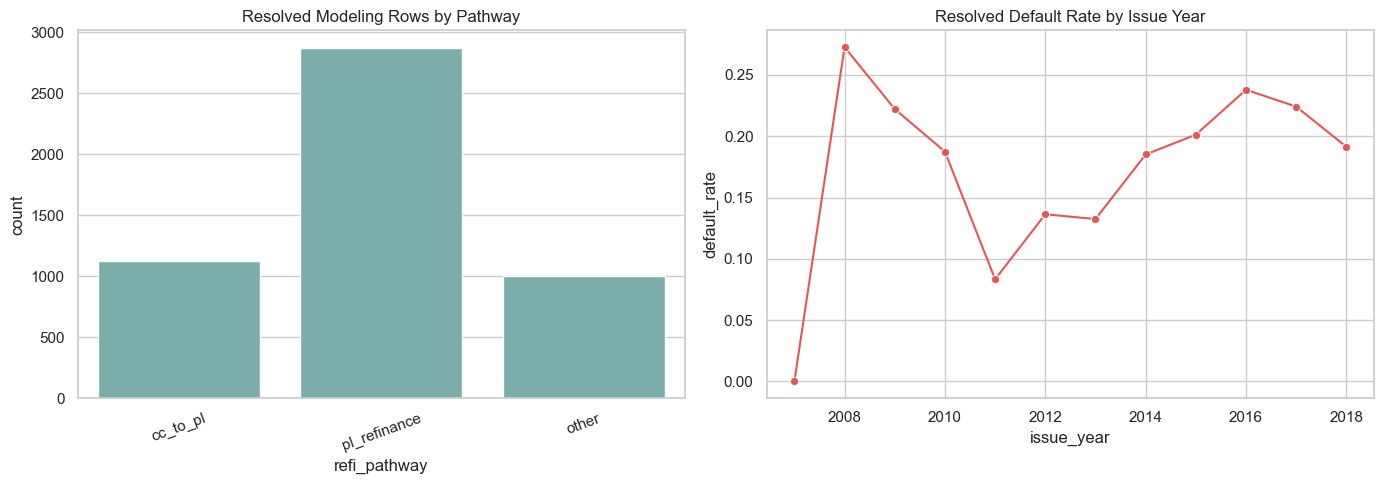

Saved: reports/figures/eda_overview.png


,refi_pathway,count,pct
0,pl_refinance,2872,57.44
1,cc_to_pl,1123,22.46
2,other,1005,20.10


In [5]:
# Pathway and temporal EDA snapshots
pathway_counts = model_df["refi_pathway"].value_counts(dropna=False).rename_axis("refi_pathway").reset_index(name="count")
pathway_counts["pct"] = (pathway_counts["count"] / pathway_counts["count"].sum() * 100).round(2)
pathway_counts.to_csv(REPORT_TAB / "pathway_counts.csv", index=False)

yearly_default = (
    model_df.dropna(subset=["issue_year"]) 
    .groupby("issue_year", as_index=False)
    .agg(default_rate=("is_default", "mean"), loans=("is_default", "size"))
)
yearly_default.to_csv(REPORT_TAB / "default_rate_by_year.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=pathway_counts, x="refi_pathway", y="count", ax=axes[0], color="#72B7B2")
axes[0].set_title("Resolved Modeling Rows by Pathway")
axes[0].set_xlabel("refi_pathway")
axes[0].tick_params(axis="x", rotation=20)

sns.lineplot(data=yearly_default, x="issue_year", y="default_rate", marker="o", ax=axes[1], color="#E45756")
axes[1].set_title("Resolved Default Rate by Issue Year")
axes[1].set_ylabel("default_rate")

plt.tight_layout()
plt.savefig(REPORT_FIG / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: reports/figures/eda_overview.png")
display(pathway_counts)




In [6]:
# Temporal split with explicit holdout test window
# Train <= 2015, Validation = 2016, Test >= 2017

df_ml = model_df.dropna(subset=["issue_year", "is_default", "int_rate_num"]).copy()

train_df = df_ml[df_ml["issue_year"] <= 2015].copy()
val_df = df_ml[df_ml["issue_year"] == 2016].copy()
test_df = df_ml[df_ml["issue_year"] >= 2017].copy()

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Test rows:", len(test_df))

if min(len(train_df), len(val_df), len(test_df)) == 0:
    raise RuntimeError("Temporal split produced an empty partition. Check issue_year coverage.")




Train rows: 3053
Val rows: 1118
Test rows: 829


In [7]:
# Feature engineering/selection outputs + training matrices

target_cls = "is_default"
target_reg = "int_rate_num"

numeric_candidates, categorical_cols = default_feature_columns(train_df)
selection_res = select_numeric_features_with_regularization(
    train_df,
    target_cls=train_df[target_cls],
    target_reg=train_df[target_reg],
    numeric_cols=numeric_candidates,
    corr_threshold=0.98,
    l1_c=0.15,
    lasso_alpha=0.0007,
    min_features=8,
    random_state=RANDOM_STATE,
)

selected_numeric_cols = selection_res.selected_numeric
feature_selection_df = selection_res.selection_table.copy()
feature_selection_df.to_csv(REPORT_TAB / "feature_selection_summary.csv", index=False)

print(f"Numeric candidates: {len(numeric_candidates)}")
print(f"Selected numeric features: {len(selected_numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print("Selected numeric columns:", selected_numeric_cols)

feature_cols = selected_numeric_cols + categorical_cols

X_train = train_df[feature_cols].copy()
y_train = train_df[target_cls].astype(int)
X_val = val_df[feature_cols].copy()
y_val = val_df[target_cls].astype(int)
X_test = test_df[feature_cols].copy()
y_test = test_df[target_cls].astype(int)

Xr_train = train_df[feature_cols].copy()
yr_train = train_df[target_reg].astype(float)
Xr_val = val_df[feature_cols].copy()
yr_val = val_df[target_reg].astype(float)
Xr_test = test_df[feature_cols].copy()
yr_test = test_df[target_reg].astype(float)

issue_date_train = pd.to_datetime(train_df["issue_date"], errors="coerce")

display(feature_selection_df.head(20))




Numeric candidates: 18
Selected numeric features: 15
Categorical features: 4
Selected numeric columns: ['annual_inc', 'annual_inc_log1p', 'dti', 'revol_util_num', 'revol_bal', 'revol_bal_log1p', 'fico_range_low', 'delinq_2yrs', 'open_acc', 'installment', 'term_months', 'installment_to_monthly_income', 'revol_bal_to_income', 'dti_x_revol_util', 'rate_x_term']


,feature,logistic_l1_abs_coef,lasso_abs_coef,dropped_by_corr,blended_rank,selected
15,rate_x_term,0.613995,6.383273,False,2.0,True
1,annual_inc_log1p,0.229010,0.174920,False,7.0,True
6,fico_range_low,0.321672,0.144742,False,8.0,True
3,revol_util_num,0.225013,0.173332,False,9.0,True
14,dti_x_revol_util,0.169063,0.178045,False,9.0,True
11,term_months,0.046590,3.223915,False,13.0,True
0,annual_inc,0.220967,0.082993,False,14.0,True
2,dti,0.138042,0.095345,False,15.0,True
5,revol_bal_log1p,0.115835,0.114825,False,15.0,True
12,installment_to_monthly_income,0.090148,0.012550,False,21.0,True


In [8]:
# Classification search (CV + randomized + grid) and calibration/threshold tuning
scoring_cls = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
    "neg_brier": "neg_brier_score",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

cls_space = classification_candidates(enable_svm=ENABLE_SVM)
if FAST_MODE:
    cls_space = {k: v for k, v in cls_space.items() if k in {"logistic_l1", "random_forest"}}
cls_outcome = run_search_suite(
    X_train=X_train,
    y_train=y_train,
    issue_date_train=issue_date_train,
    numeric_cols=selected_numeric_cols,
    categorical_cols=categorical_cols,
    candidates=cls_space,
    scoring=scoring_cls,
    refit_metric="pr_auc",
    random_iter=RANDOM_SEARCH_ITERS,
    grid_top_k=GRID_TOP_K,
    cv_splits=CV_SPLITS,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    metric_transform={"neg_log_loss": "neg_to_pos", "neg_brier": "neg_to_pos"},
)

cls_leaderboard = cls_outcome.leaderboard.copy()
cls_leaderboard.to_csv(REPORT_TAB / "risk_classification_model_search.csv", index=False)

# Fit/evaluate each tuned candidate on train -> val/test at threshold 0.5
cls_val_rows = []
cls_test_rows = []
trained_cls = {}
for name, est in cls_outcome.best_estimators.items():
    model = clone(est)
    model.fit(X_train, y_train)
    trained_cls[name] = model

    val_proba = model.predict_proba(X_val)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    val_metrics = classification_metrics_from_proba(y_val, val_proba, threshold=0.5)
    test_metrics = classification_metrics_from_proba(y_test, test_proba, threshold=0.5)
    cls_val_rows.append({"model": name, **val_metrics})
    cls_test_rows.append({"model": name, **test_metrics})

cls_val_df = pd.DataFrame(cls_val_rows).sort_values("pr_auc", ascending=False)
cls_test_df = pd.DataFrame(cls_test_rows).sort_values("pr_auc", ascending=False)

best_cls_name = cls_val_df.iloc[0]["model"]
base_cls_model = trained_cls[best_cls_name]

# Probability calibration on validation set (prefit), keep if Brier improves.
val_proba_uncal = base_cls_model.predict_proba(X_val)[:, 1]
calibration_summary = []
calibration_summary.append(
    {
        "model": best_cls_name,
        "variant": "uncalibrated",
        "val_brier": classification_metrics_from_proba(y_val, val_proba_uncal)["brier"],
    }
)

final_cls_model = base_cls_model
calibration_selected = "uncalibrated"
try:
    calibrated = CalibratedClassifierCV(base_cls_model, method="sigmoid", cv="prefit")
    calibrated.fit(X_val, y_val)
    val_proba_cal = calibrated.predict_proba(X_val)[:, 1]
    cal_brier = classification_metrics_from_proba(y_val, val_proba_cal)["brier"]
    calibration_summary.append({"model": best_cls_name, "variant": "sigmoid_prefit", "val_brier": cal_brier})
    if cal_brier <= calibration_summary[0]["val_brier"]:
        final_cls_model = calibrated
        calibration_selected = "sigmoid_prefit"
except Exception as exc:
    calibration_summary.append({"model": best_cls_name, "variant": "calibration_failed", "val_brier": np.nan, "error": str(exc)})

calibration_df = pd.DataFrame(calibration_summary)
calibration_df.to_csv(REPORT_TAB / "risk_calibration_summary.csv", index=False)

val_proba_final = final_cls_model.predict_proba(X_val)[:, 1]
threshold_table = threshold_sweep(y_val, val_proba_final, thresholds=np.round(np.arange(0.05, 0.56, 0.05), 2))
threshold_table.to_csv(REPORT_TAB / "risk_threshold_sweep.csv", index=False)

selected_threshold = select_threshold(
    threshold_table,
    objective="f1",
    min_precision=MIN_PRECISION_FOR_THRESHOLD,
)

champion_val_metrics = classification_metrics_from_proba(y_val, val_proba_final, threshold=selected_threshold.threshold)
champion_test_proba = final_cls_model.predict_proba(X_test)[:, 1]
champion_test_metrics = classification_metrics_from_proba(y_test, champion_test_proba, threshold=selected_threshold.threshold)

champion_cls_df = pd.DataFrame(
    [
        {
            "model": best_cls_name,
            "calibration": calibration_selected,
            "threshold": selected_threshold.threshold,
            "split": "val",
            **champion_val_metrics,
        },
        {
            "model": best_cls_name,
            "calibration": calibration_selected,
            "threshold": selected_threshold.threshold,
            "split": "test",
            **champion_test_metrics,
        },
    ]
)
champion_cls_df.to_csv(REPORT_TAB / "risk_classification_champion_metrics.csv", index=False)

cls_val_df.to_csv(REPORT_TAB / "risk_classification_val_metrics.csv", index=False)
cls_test_df.to_csv(REPORT_TAB / "risk_classification_test_metrics.csv", index=False)

print("Best classification champion:", best_cls_name)
print("Calibration selected:", calibration_selected)
print("Selected threshold:", round(selected_threshold.threshold, 4), f"(objective={selected_threshold.objective})")
display(cls_leaderboard.head(10))
display(cls_val_df)
display(champion_cls_df)





Best classification champion: logistic_l1
Calibration selected: uncalibrated
Selected threshold: 0.4 (objective=f1)


,model,stage,rows_used,cv_primary_raw,best_params,pr_auc,roc_auc,neg_log_loss,neg_brier,f1,precision,recall,neg_log_loss_human,neg_brier_human
0,logistic_l1,random_search,3053,0.380977,{'model__C': 0.1},0.380977,0.721318,-0.614702,-0.214135,0.436748,0.321128,0.682483,0.614702,0.214135
1,random_forest,random_search,3053,0.367951,"{'model__n_estimators': 200, 'model__min_sampl...",0.367951,0.714648,-0.524126,-0.175823,0.399491,0.360593,0.451489,0.524126,0.175823


,model,roc_auc,pr_auc,log_loss,brier,precision,recall,f1
0,logistic_l1,0.696217,0.397600,0.628950,0.218954,0.350318,0.620301,0.447761
1,random_forest,0.692224,0.383591,0.557777,0.189703,0.401961,0.462406,0.430070


,model,calibration,threshold,split,roc_auc,pr_auc,log_loss,brier,precision,recall,f1
0,logistic_l1,uncalibrated,0.4,val,0.696217,0.397600,0.628950,0.218954,0.322775,0.804511,0.46071
1,logistic_l1,uncalibrated,0.4,test,0.692763,0.353209,0.649992,0.223435,0.288270,0.810056,0.42522


In [9]:
# Regression search (CV + randomized + grid)
scoring_reg = {
    "neg_rmse": "neg_root_mean_squared_error",
    "neg_mae": "neg_mean_absolute_error",
    "neg_mape": "neg_mean_absolute_percentage_error",
    "r2": "r2",
}

reg_space = regression_candidates(enable_svm=ENABLE_SVM)
if FAST_MODE:
    reg_space = {k: v for k, v in reg_space.items() if k in {"ridge", "lasso"}}
reg_outcome = run_search_suite(
    X_train=Xr_train,
    y_train=yr_train,
    issue_date_train=issue_date_train,
    numeric_cols=selected_numeric_cols,
    categorical_cols=categorical_cols,
    candidates=reg_space,
    scoring=scoring_reg,
    refit_metric="neg_rmse",
    random_iter=RANDOM_SEARCH_ITERS,
    grid_top_k=GRID_TOP_K,
    cv_splits=CV_SPLITS,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    metric_transform={"neg_rmse": "neg_to_pos", "neg_mae": "neg_to_pos", "neg_mape": "neg_to_pos"},
)

reg_leaderboard = reg_outcome.leaderboard.copy()
reg_leaderboard.to_csv(REPORT_TAB / "rate_regression_model_search.csv", index=False)

reg_val_rows = []
reg_test_rows = []
trained_reg = {}
for name, est in reg_outcome.best_estimators.items():
    model = clone(est)
    model.fit(Xr_train, yr_train)
    trained_reg[name] = model

    val_pred = model.predict(Xr_val)
    test_pred = model.predict(Xr_test)

    val_metrics = regression_metrics(yr_val, val_pred)
    test_metrics = regression_metrics(yr_test, test_pred)
    reg_val_rows.append({"model": name, **val_metrics})
    reg_test_rows.append({"model": name, **test_metrics})

reg_val_df = pd.DataFrame(reg_val_rows).sort_values("rmse", ascending=True)
reg_test_df = pd.DataFrame(reg_test_rows).sort_values("rmse", ascending=True)

best_reg_name = reg_val_df.iloc[0]["model"]
final_reg_model = trained_reg[best_reg_name]

reg_val_df.to_csv(REPORT_TAB / "rate_regression_val_metrics.csv", index=False)
reg_test_df.to_csv(REPORT_TAB / "rate_regression_test_metrics.csv", index=False)

print("Best regression champion:", best_reg_name)
display(reg_leaderboard.head(10))
display(reg_val_df)





Best regression champion: lasso


,model,stage,rows_used,cv_primary_raw,best_params,neg_rmse,neg_mae,neg_mape,r2,neg_rmse_human,neg_mae_human,neg_mape_human
0,lasso,random_search,3053,-0.666671,{'model__alpha': 0.0007},-0.666671,-0.547643,-0.046725,0.976555,0.666671,0.547643,0.046725
1,ridge,random_search,3053,-0.673850,{'model__alpha': 0.01},-0.673850,-0.555574,-0.047149,0.976055,0.673850,0.555574,0.047149


,model,rmse,mae,mape,r2
1,lasso,0.715712,0.475957,0.037368,0.979424
0,ridge,0.716446,0.480204,0.037453,0.979382


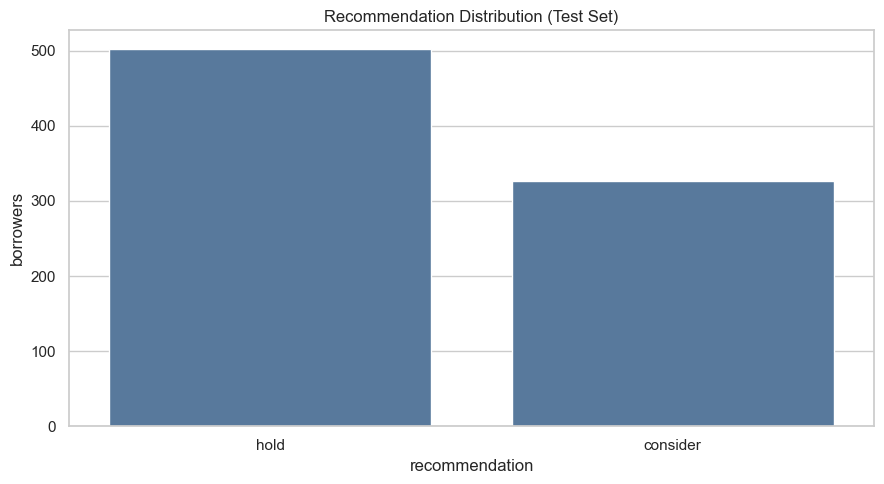

Saved recommendation summary, sample, and policy simulation outputs.
Top 5 rows (recommendation preview):
                id  refi_pathway  pd_score  pred_rate  monthly_savings  risk_adjusted_savings recommendation
547122   119279916  pl_refinance  0.357118  13.598733        19.607911              12.605581       consider
921369   108906681  pl_refinance  0.547835  12.909988        27.885973              12.609048           hold
470287   129056676         other  0.188030   8.260263        17.546428              14.247166       consider
774255   139799241         other  0.316383  12.926496        11.792679               8.061670       consider
1590592  131564906  pl_refinance  0.329986  10.223683        31.381277              21.025884       consider


,recommendation,borrowers,avg_pd,median_savings,avg_savings,avg_risk_adjusted_savings
1,hold,502,0.591409,63.679119,98.880175,37.653910
0,consider,326,0.249960,35.642738,76.187335,57.670766


,hold_threshold,min_savings,consider_rate,consider_count,avg_pd_consider,avg_savings_consider
0,0.15,0,0.109903,91,0.119678,78.662943
1,0.15,100,0.020531,17,0.114485,253.760809
2,0.15,300,0.007246,6,0.119541,417.352270
3,0.15,500,0.002415,2,0.127893,506.340224
4,0.20,0,0.164251,136,0.136980,77.694344
5,0.20,100,0.032609,27,0.137718,237.778455
6,0.20,300,0.009662,8,0.133492,440.131457
7,0.20,500,0.003623,3,0.141216,576.162069
8,0.25,0,0.183575,152,0.146189,80.280231
9,0.25,100,0.037440,31,0.147483,244.386767


In [10]:
# Recommendation layer + policy simulation
rec_df = test_df.copy().dropna(subset=feature_cols + ["int_rate_num", "installment"])

rec_pd_score = final_cls_model.predict_proba(rec_df[feature_cols])[:, 1]
rec_pred_rate = final_reg_model.predict(rec_df[feature_cols])

hold_threshold = float(selected_threshold.threshold)
recommendation_df = apply_recommendation_policy(
    rec_df,
    pd_score=rec_pd_score,
    pred_rate=rec_pred_rate,
    hold_threshold=hold_threshold,
    consider_min_savings=0.0,
    strong_min_savings=1500.0,
    strong_max_pd=0.15,
)

rec_summary = recommendation_df.groupby("recommendation", as_index=False).agg(
    borrowers=("recommendation", "size"),
    avg_pd=("pd_score", "mean"),
    median_savings=("monthly_savings", "median"),
    avg_savings=("monthly_savings", "mean"),
    avg_risk_adjusted_savings=("risk_adjusted_savings", "mean"),
).sort_values("borrowers", ascending=False)

policy_table = policy_simulation_table(
    recommendation_df,
    hold_thresholds=[0.15, 0.20, 0.25, 0.30, 0.35],
    min_savings_values=[0, 100, 300, 500],
)

rec_summary.to_csv(REPORT_TAB / "recommendation_summary.csv", index=False)
recommendation_df[[
    "id", "refi_pathway", "pd_score", "pred_rate", "scenario_current_rate",
    "monthly_savings", "risk_adjusted_savings", "recommendation",
]].head(5000).to_csv(REPORT_TAB / "recommendation_sample.csv", index=False)
policy_table.to_csv(REPORT_TAB / "policy_simulation_table.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=rec_summary, x="recommendation", y="borrowers", ax=ax, color="#4C78A8")
ax.set_title("Recommendation Distribution (Test Set)")
plt.tight_layout()
plt.savefig(REPORT_FIG / "recommendation_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

preview_cols = [
    "id", "refi_pathway", "pd_score", "pred_rate", "monthly_savings", "risk_adjusted_savings", "recommendation"
]
print("Saved recommendation summary, sample, and policy simulation outputs.")
print("Top 5 rows (recommendation preview):")
print(recommendation_df[preview_cols].head(5))
display(rec_summary)
display(policy_table.head(10))




In [11]:
# Consolidated summary payload for reporting
summary_payload = {
    "problem_question": "Predict refinance suitability, estimate refinance rates/savings, and generate pathway-aware recommendations.",
    "config": {
        "MODEL_MAX_ROWS": MODEL_MAX_ROWS,
        "CV_SPLITS": CV_SPLITS,
        "RANDOM_SEARCH_ITERS": RANDOM_SEARCH_ITERS,
        "GRID_TOP_K": GRID_TOP_K,
        "ENABLE_SVM": ENABLE_SVM,
        "FAST_MODE": FAST_MODE,
    },
    "rows_raw": int(len(raw_df)),
    "rows_resolved_modeling": int(len(model_df)),
    "unresolved_excluded": int((raw_df["is_unresolved"] == 1).sum()),
    "default_rate_resolved": float(model_df["is_default"].mean()),
    "feature_counts": {
        "numeric_selected": int(len(selected_numeric_cols)),
        "categorical": int(len(categorical_cols)),
        "total_model_features": int(len(feature_cols)),
    },
    "best_classification_model": best_cls_name,
    "classification_calibration": calibration_selected,
    "classification_threshold": float(selected_threshold.threshold),
    "best_regression_model": best_reg_name,
    "classification_test_metrics_champion": champion_test_metrics,
    "regression_test_metrics": reg_test_df.set_index("model").to_dict(orient="index"),
    "recommendation_counts": recommendation_df["recommendation"].value_counts().to_dict(),
}

with open(REPORT_TAB / "pipeline_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print(json.dumps(summary_payload, indent=2)[:4000])
print("Saved: reports/tables/pipeline_summary.json")





{
  "problem_question": "Predict refinance suitability, estimate refinance rates/savings, and generate pathway-aware recommendations.",
  "config": {
    "MODEL_MAX_ROWS": 5000,
    "CV_SPLITS": 2,
    "RANDOM_SEARCH_ITERS": 1,
    "GRID_TOP_K": 0,
    "ENABLE_SVM": false,
    "FAST_MODE": true
  },
  "rows_raw": 2260701,
  "rows_resolved_modeling": 5000,
  "unresolved_excluded": 912569,
  "default_rate_resolved": 0.1982,
  "feature_counts": {
    "numeric_selected": 15,
    "categorical": 4,
    "total_model_features": 19
  },
  "best_classification_model": "logistic_l1",
  "classification_calibration": "uncalibrated",
  "classification_threshold": 0.4,
  "best_regression_model": "lasso",
  "classification_test_metrics_champion": {
    "roc_auc": 0.6927632144391922,
    "pr_auc": 0.3532089936427266,
    "log_loss": 0.6499916320656727,
    "brier": 0.2234351886178219,
    "precision": 0.2882703777335984,
    "recall": 0.8100558659217877,
    "f1": 0.4252199413489736
  },
  "regression_

## Results (Summary)

This notebook now produces:
- Feature-engineering and feature-selection artifacts,
- Classification/regression model search leaderboards (random + grid),
- Calibrated risk model outputs and threshold sweep artifacts,
- Recommendation outputs and policy simulation tables,
- Consolidated metrics in `reports/tables/pipeline_summary.json`.


## Output Files To Review

Core artifacts generated by this run:
- `reports/tables/feature_selection_summary.csv`
- `reports/tables/risk_classification_model_search.csv`
- `reports/tables/rate_regression_model_search.csv`
- `reports/tables/risk_threshold_sweep.csv`
- `reports/tables/risk_classification_champion_metrics.csv`
- `reports/tables/policy_simulation_table.csv`
- `reports/tables/pipeline_summary.json`


## Notes and Limitations

1. RBF SVM/SVR are included but can be expensive on large datasets; row caps are applied inside search.
2. Public structural analog data is not lender-specific production data.
3. Recommendation savings remain scenario-based and should be replaced with live borrower current-rate context in production.
4. Final production rollout should use shadow-mode monitoring, calibration audits, and fairness checks before automation.
